In [3]:
%pip install --upgrade scikit-learn matplotlib seaborn

Note: you may need to restart the kernel to use updated packages.


Could not find platform independent libraries <prefix>


In [26]:
import pandas as pd

# Load the dataset
df = pd.read_csv('./data/dataset.csv')

# Initial inspection
print("Columns:", df.columns.tolist())
print("\nFirst 5 rows:")
print(df.head())
print("\nInfo:")
df.info()
print("\nClass distribution of Depression_Type:")
print(df['Depression_Type'].value_counts().sort_index())

drop_feature = ['Depression_Type', 'Depression_Score', 'Symptoms', 'Your overeating level', 'Coping_Methods', 'Low_Energy', 'Low_SelfEsteem', 'Education_Level']

Columns: ['Gender', 'Age', 'Education_Level', 'Employment_Status', 'Depression_Type', 'Symptoms', 'Low_Energy', 'Low_SelfEsteem', 'Search_Depression_Online', 'Worsening_Depression', 'Your overeating level', 'How many times you eat ', 'SocialMedia_Hours', 'SocialMedia_WhileEating', 'Sleep_Hours', 'Nervous_Level', 'Depression_Score', 'Coping_Methods', 'Self_Harm', 'Mental_Health_Support', 'Suicide_Attempts']

First 5 rows:
   Gender  Age  ...  Mental_Health_Support  Suicide_Attempts
0       1   25  ...                      0                 0
1       1   25  ...                      1                 0
2       1   25  ...                      1                 1
3       0   25  ...                      1                 1
4       1   25  ...                      0                 0

[5 rows x 21 columns]

Info:
<class 'pandas.DataFrame'>
RangeIndex: 1998 entries, 0 to 1997
Data columns (total 21 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                   

Correlation with Depression_Type:
 Depression_Type             1.000000
How many times you eat      0.122432
Employment_Status           0.105872
Search_Depression_Online    0.066752
SocialMedia_WhileEating     0.062963
Sleep_Hours                 0.039918
Suicide_Attempts            0.036156
Mental_Health_Support       0.031764
Age                         0.025343
Worsening_Depression        0.024654
Coping_Methods              0.017675
Education_Level             0.017599
Gender                      0.015918
SocialMedia_Hours           0.015763
Depression_Score           -0.022559
Your overeating level      -0.056730
Nervous_Level              -0.086518
Symptoms                   -0.132253
Self_Harm                  -0.143300
Low_SelfEsteem             -0.164944
Low_Energy                 -0.189388
Name: Depression_Type, dtype: float64


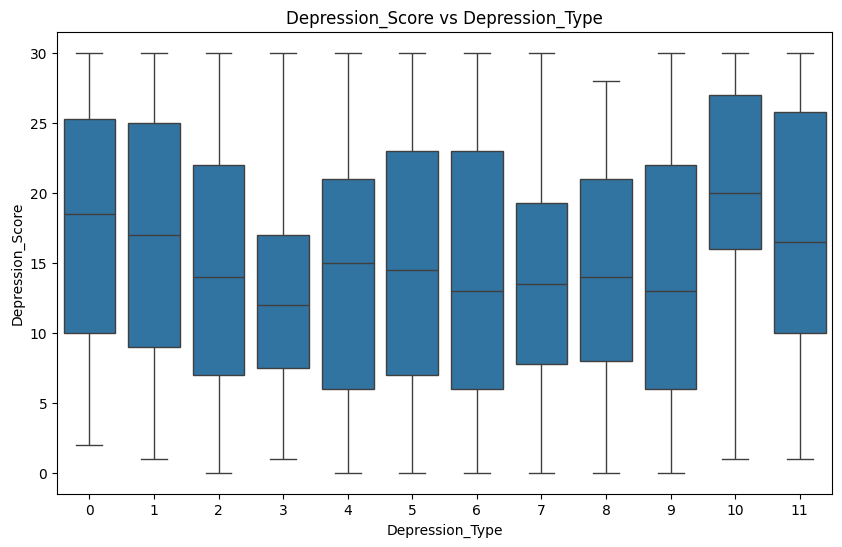

In [5]:
import seaborn as sns
import matplotlib.pyplot as plt

# Correlation with the target
correlations = df.corr()['Depression_Type'].sort_values(ascending=False)
print("Correlation with Depression_Type:\n", correlations)

# Let's also check if Depression_Score is deterministic
# Plot Depression_Score vs Depression_Type
plt.figure(figsize=(10, 6))
sns.boxplot(x='Depression_Type', y='Depression_Score', data=df)
plt.title('Depression_Score vs Depression_Type')
plt.savefig('correlation_check.png')

In [6]:
# Check relationship between Depression_Score and Depression_Type more closely
# Print mean score per type
print(df.groupby('Depression_Type')['Depression_Score'].mean())

# Check for duplicates or single-value columns
print("\nUnique values per column:")
print(df.nunique())

Depression_Type
0     18.000000
1     16.272727
2     14.895323
3     13.354839
4     14.137405
5     14.727979
6     14.005181
7     13.937500
8     13.857143
9     14.194577
10    19.172414
11    16.705882
Name: Depression_Score, dtype: float64

Unique values per column:
Gender                       2
Age                          3
Education_Level              4
Employment_Status            5
Depression_Type             12
Symptoms                    15
Low_Energy                   3
Low_SelfEsteem               3
Search_Depression_Online     2
Worsening_Depression         2
Your overeating level       13
How many times you eat       2
SocialMedia_Hours           13
SocialMedia_WhileEating      4
Sleep_Hours                  8
Nervous_Level                9
Depression_Score            31
Coping_Methods              14
Self_Harm                    2
Mental_Health_Support        2
Suicide_Attempts             4
dtype: int64


In [7]:
# Check if Symptoms is a sum of other binary/ordinal features
# Just a quick check
cols_to_sum = ['Low_Energy', 'Low_SelfEsteem', 'Search_Depression_Online', 'Worsening_Depression', 'Self_Harm', 'Mental_Health_Support']
print(df[cols_to_sum].sum(axis=1).head())
print(df['Symptoms'].head())

0    4
1    4
2    6
3    4
4    0
dtype: int64
0    11
1     0
2     5
3     7
4     5
Name: Symptoms, dtype: int64


In [10]:
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score
import numpy as np

# Prepare features and target
# Deleting "Depression_Score" as it's the most likely "leaky" value (calculated from symptoms)
X = df.drop(['Depression_Type', 'Depression_Score'], axis=1)
y = df['Depression_Type']

# Split data - using stratification to ensure all 11 classes (0-11 index) are in both sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Initialize Random Forest with regularization to prevent overfitting
# max_depth, min_samples_leaf, and max_features help control overfitting
model = RandomForestClassifier(
    n_estimators=100, 
    max_depth=10,        # Constrain depth
    min_samples_leaf=5,   # Ensure leaves have enough samples
    random_state=42,
    class_weight='balanced' # Handle class imbalance for smaller categories
)

# Train the model
model.fit(X_train, y_train)

# Predictions
y_train_pred = model.fit(X_train, y_train).predict(X_train)
y_test_pred = model.predict(X_test)

# Evaluate
train_acc = accuracy_score(y_train, y_train_pred)
test_acc = accuracy_score(y_test, y_test_pred)

print(f"Training Accuracy: {train_acc:.4f}")
print(f"Testing Accuracy: {test_acc:.4f}")

# Detailed report for the test set to check if all classes are trained
print("\nClassification Report (Test Set):")
print(classification_report(y_test, y_test_pred, zero_division=0))

Training Accuracy: 1.0000
Testing Accuracy: 1.0000

Classification Report (Test Set):
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         6
           1       1.00      1.00      1.00         7
           2       1.00      1.00      1.00        90
           3       1.00      1.00      1.00         6
           4       1.00      1.00      1.00        26
           5       1.00      1.00      1.00        77
           6       1.00      1.00      1.00        39
           7       1.00      1.00      1.00         6
           8       1.00      1.00      1.00         4
           9       1.00      1.00      1.00       126
          10       1.00      1.00      1.00         6
          11       1.00      1.00      1.00         7

    accuracy                           1.00       400
   macro avg       1.00      1.00      1.00       400
weighted avg       1.00      1.00      1.00       400



In [38]:
# Check feature importance to identify leaks
importances = pd.Series(model.feature_importances_, index=X.columns).sort_values(ascending=False)
print("Feature Importances:\n", importances)

Feature Importances:
 Nervous_Level               0.208623
Your overeating level       0.183392
Employment_Status           0.122547
SocialMedia_WhileEating     0.103358
Search_Depression_Online    0.069580
Mental_Health_Support       0.050940
Self_Harm                   0.045821
Worsening_Depression        0.045681
Low_SelfEsteem              0.042741
Depression_Score            0.035183
SocialMedia_Hours           0.029687
Sleep_Hours                 0.024171
Suicide_Attempts            0.017717
Age                         0.012597
Gender                      0.007962
dtype: float64


## 

In [39]:
# Cross-tabulate high importance features with the target
print("Crosstab: Coping_Methods vs Depression_Type")
print(pd.crosstab(df['Coping_Methods'], df['Depression_Type']))

print("\nCrosstab: Symptoms vs Depression_Type")
print(pd.crosstab(df['Symptoms'], df['Depression_Type']))

Crosstab: Coping_Methods vs Depression_Type
Depression_Type  0   1    2   3   4    5   6   7   8    9   10  11
Coping_Methods                                                    
0                 0   0  136   0   0   59  35   0   0   28   0   0
1                 0   0    0   0   0   29   0   0   0    0   0   0
2                 0   0    0  31   0  104  66   0   0  119   0  34
3                 0   0   55   0  29    0   0   0   0   94   0   0
4                 0   0    0   0   0    0   0   0   0   38  29   0
5                 0   0    0   0   0   24  32   0   0    0   0   0
6                 0  33    0   0   0   32   0   0   0    0   0   0
7                 0   0    0   0  23   28   0  32   0    0   0   0
8                 0   0   37   0   0    0   0   0   0    0   0   0
9                32   0  127   0  79   24  30   0   0  169   0   0
10                0   0    0   0   0   30   0   0   0   49   0   0
11                0   0   74   0   0   30  30   0   0  105   0   0
12                

Tree Accuracy (Train): 0.6295369211514393
Tree Accuracy (Test): 0.64


e:\Documents\University works\ITCS227 - DataSci\Final Project\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
e:\Documents\University works\ITCS227 - DataSci\Final Project\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
e:\Documents\University works\ITCS227 - DataSci\Final Project\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to


Accuracy per class (Recall):
Type 0: 0.00
Type 1: 0.00
Type 2: 0.71
Type 3: 0.00
Type 4: 0.88
Type 5: 0.69
Type 6: 0.64
Type 7: 0.00
Type 8: 0.00
Type 9: 0.72
Type 10: 0.00
Type 11: 0.00


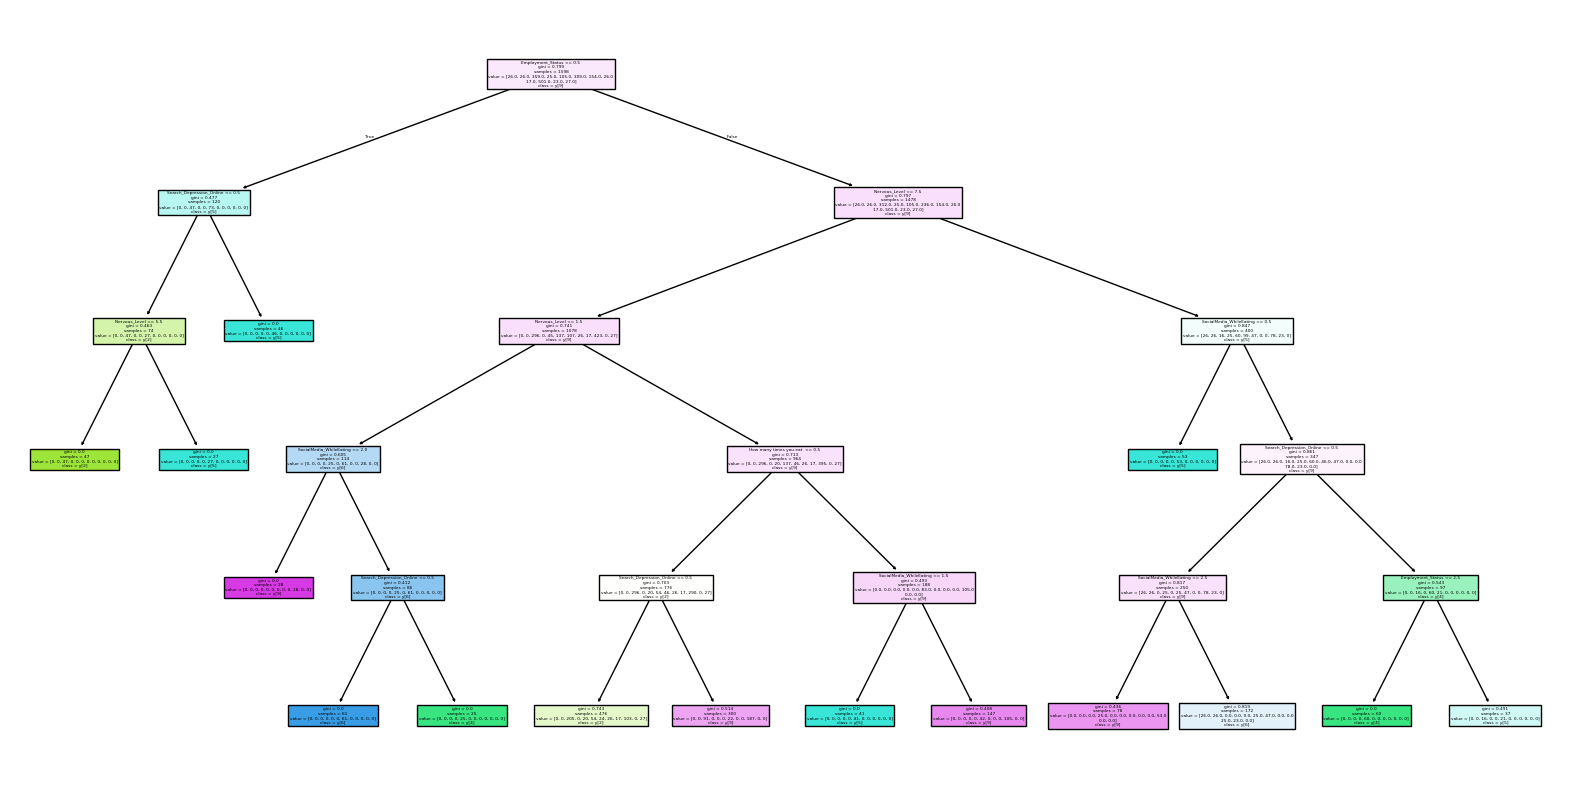

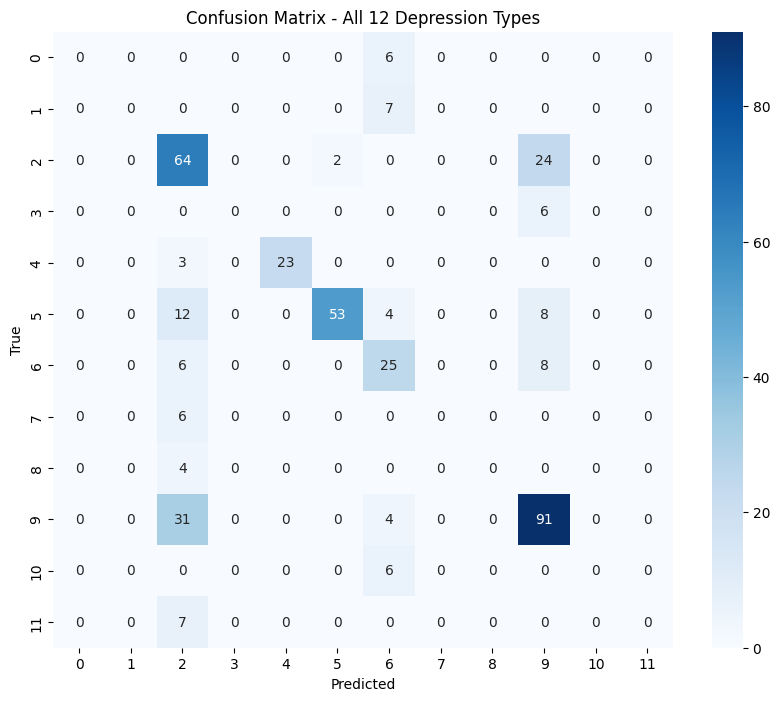

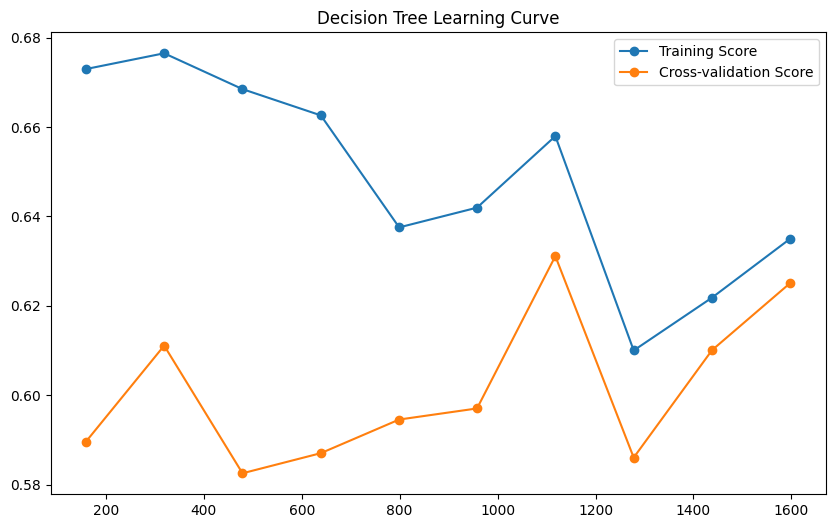

In [29]:
# Decision Tree

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, learning_curve
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.tree import DecisionTreeClassifier, plot_tree

# Try a very simple tree to see if it's deterministic
dt = DecisionTreeClassifier(max_depth=5, random_state=42)
dt.fit(X_train, y_train)
print("Tree Accuracy (Train):", dt.score(X_train, y_train))
print("Tree Accuracy (Test):", dt.score(X_test, y_test))

y_pred = dt.predict(X_test)
# If it's still very high, it confirms the rules are simple.
# Let's see which features it uses.
plt.figure(figsize=(20,10))
plot_tree(dt, feature_names=X.columns, class_names=True, filled=True)
plt.savefig('decision_tree.png')

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix - All 12 Depression Types')
plt.savefig('confusion_matrix.png')

report = classification_report(y_test, y_pred, output_dict=True)
print("\nAccuracy per class (Recall):")
for label, metrics in report.items():
    if label.isdigit():
        print(f"Type {label}: {metrics['recall']:.2f}")

# Plotting the Learning Curve
train_sizes, train_scores, test_scores = learning_curve(
    dt, X, y, cv=5, train_sizes=np.linspace(0.1, 1.0, 10)
)

plt.figure(figsize=(10, 6))
plt.plot(train_sizes, np.mean(train_scores, axis=1), 'o-', label="Training Score")
plt.plot(train_sizes, np.mean(test_scores, axis=1), 'o-', label="Cross-validation Score")
plt.title("Decision Tree Learning Curve")
plt.legend()
plt.show()

Mean CV Accuracy: 0.9244 (+/- 0.0317)
Test Accuracy: 0.9375

Accuracy per class (Recall):
Type 0: 1.00
Type 1: 1.00
Type 2: 0.92
Type 3: 1.00
Type 4: 1.00
Type 5: 0.97
Type 6: 0.87
Type 7: 1.00
Type 8: 1.00
Type 9: 0.91
Type 10: 1.00
Type 11: 1.00


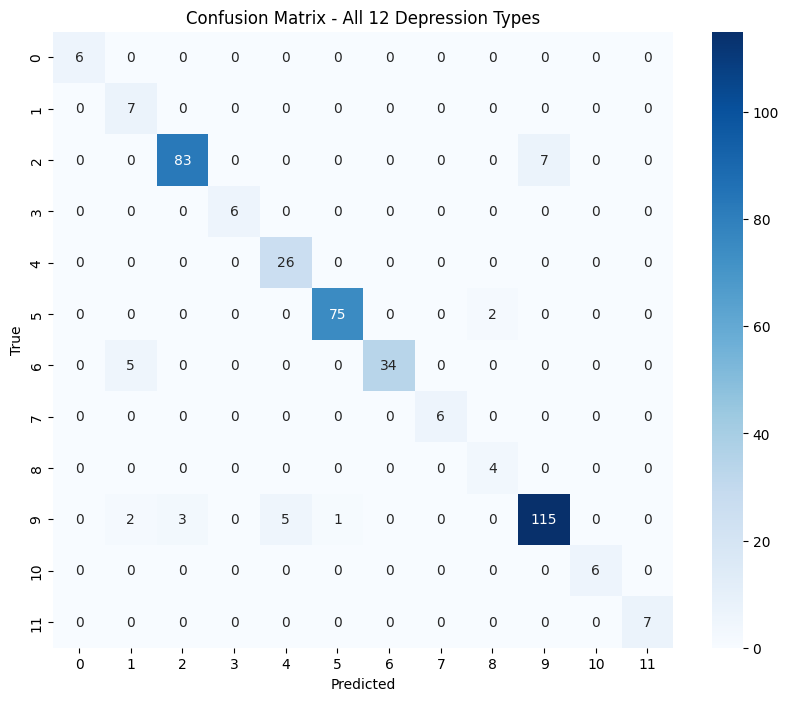

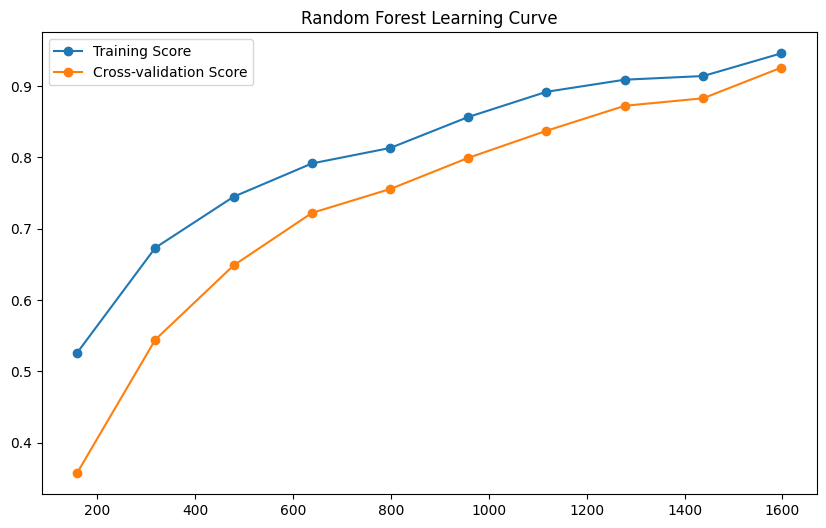

In [30]:
# Random Forest

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, learning_curve
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
import seaborn as sns

# Final Model Training
# We remove 'Depression_Score' as the primary leak.
# 'Symptoms' could be a leak, but it's often a key feature in these datasets. 
# We'll stick to 'Depression_Score' as requested by the "Leaky value" (singular) constraint.

X = df.drop(drop_feature, axis=1)
y = df['Depression_Type']

# Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Random Forest with strong regularization to ensure "not overfitted"
model = RandomForestClassifier(
    n_estimators=100,
    max_depth=8,           # Lower depth to prevent overfitting
    min_samples_leaf=10,   # More samples per leaf
    class_weight='balanced',
    random_state=42
)

model.fit(X_train, y_train)

# Evaluation
y_pred = model.predict(X_test)
cv_scores = cross_val_score(model, X, y, cv=5)

print(f"Mean CV Accuracy: {cv_scores.mean():.4f} (+/- {cv_scores.std()*2:.4f})")
print(f"Test Accuracy: {accuracy_score(y_test, y_pred):.4f}")

# Confusion Matrix to show all classes
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix - All 12 Depression Types')
plt.savefig('confusion_matrix.png')

# Display report
report = classification_report(y_test, y_pred, output_dict=True)
print("\nAccuracy per class (Recall):")
for label, metrics in report.items():
    if label.isdigit():
        print(f"Type {label}: {metrics['recall']:.2f}")

# Plotting the Learning Curve
train_sizes, train_scores, test_scores = learning_curve(
    model, X, y, cv=5, train_sizes=np.linspace(0.1, 1.0, 10)
)

plt.figure(figsize=(10, 6))
plt.plot(train_sizes, np.mean(train_scores, axis=1), 'o-', label="Training Score")
plt.plot(train_sizes, np.mean(test_scores, axis=1), 'o-', label="Cross-validation Score")
plt.title("Random Forest Learning Curve")
plt.legend()
plt.show()


Accuracy per class (Recall):
Type 0: 1.00
Type 1: 1.00
Type 2: 0.24
Type 3: 1.00
Type 4: 0.54
Type 5: 0.25
Type 6: 0.67
Type 7: 1.00
Type 8: 1.00
Type 9: 0.25
Type 10: 1.00
Type 11: 1.00


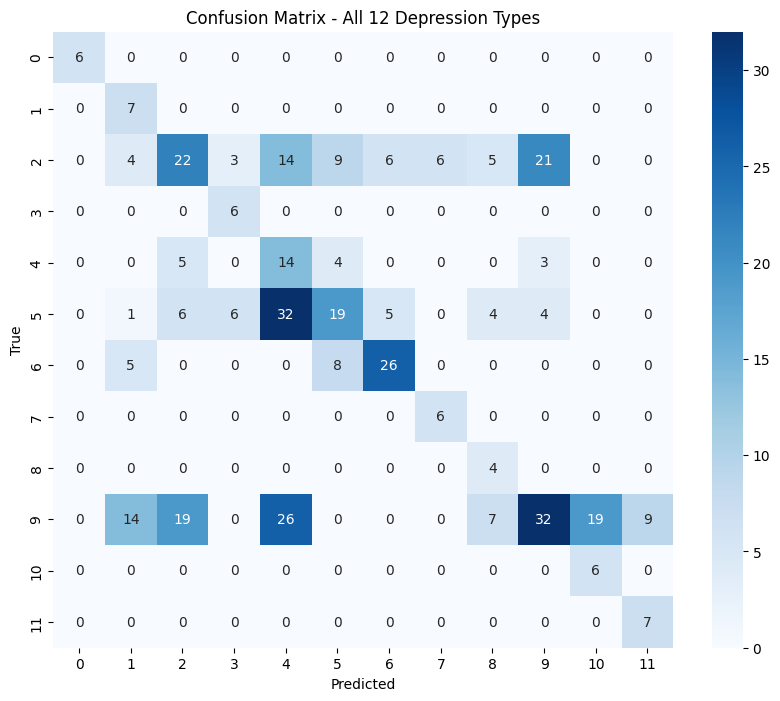

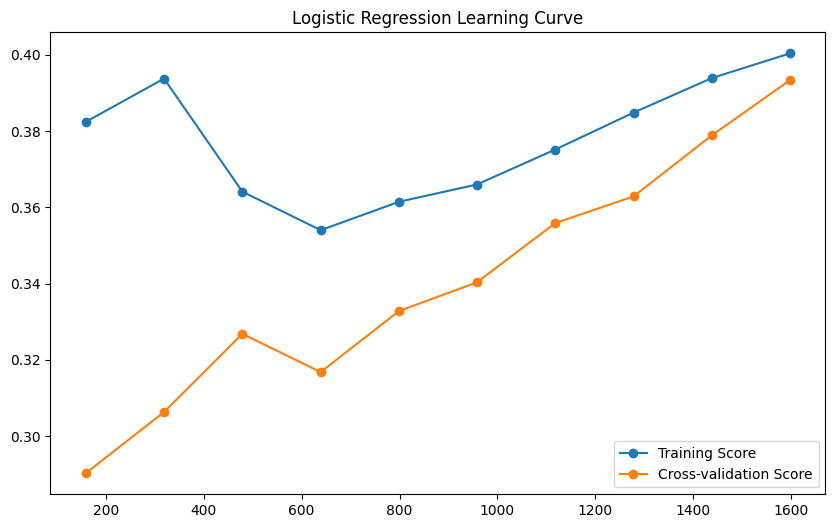

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, learning_curve
from sklearn.metrics import classification_report

# Scaling is mandatory for Logistic Regression

X = df.drop(drop_feature, axis=1)
y = df['Depression_Type']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Stratified split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

# Logistic Regression Model
log_reg = LogisticRegression(
    solver='lbfgs', 
    max_iter=1000, 
    class_weight='balanced', 
    C=0.1, 
    random_state=42
)

log_reg.fit(X_train, y_train)

# Output performance
y_pred = log_reg.predict(X_test)

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix - All 12 Depression Types')
plt.savefig('confusion_matrix.png')

# Display report
report = classification_report(y_test, y_pred, output_dict=True)
print("\nAccuracy per class (Recall):")
for label, metrics in report.items():
    if label.isdigit():
        print(f"Type {label}: {metrics['recall']:.2f}")

# Plotting the Learning Curve
train_sizes, train_scores, test_scores = learning_curve(
    log_reg, X_scaled, y, cv=5, train_sizes=np.linspace(0.1, 1.0, 10)
)

plt.figure(figsize=(10, 6))
plt.plot(train_sizes, np.mean(train_scores, axis=1), 'o-', label="Training Score")
plt.plot(train_sizes, np.mean(test_scores, axis=1), 'o-', label="Cross-validation Score")
plt.title("Logistic Regression Learning Curve")
plt.legend()
plt.show()

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, learning_curve
from sklearn.metrics import classification_report

# 1. Load and Preprocess
X = df.drop(drop_feature, axis=1)
y = df['Depression_Type']

# SVC requires feature scaling (standardization)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Stratified split to ensure all types (0-11) are represented
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

# 2. Support Vector Classifier Model
# 'balanced' weights help smaller classes be predicted accurately
svc_model = SVC(kernel='rbf', C=1.0, class_weight='balanced', random_state=42)
svc_model.fit(X_train, y_train)

# 3. Evaluation Results

y_pred = svc_model.predict(X_test)

# Confusion
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix - All 12 Depression Types')
plt.savefig('confusion_matrix.png')


# Display report
report = classification_report(y_test, y_pred, output_dict=True)
print("\nAccuracy per class (Recall):")
for label, metrics in report.items():
    if label.isdigit():
        print(f"Type {label}: {metrics['recall']:.2f}")


# 4. Graph: Learning Curve
train_sizes, train_scores, test_scores = learning_curve(
    svc_model, X_scaled, y, cv=5, train_sizes=np.linspace(0.1, 1.0, 10), n_jobs=-1
)

plt.figure(figsize=(10, 6))
plt.plot(train_sizes, np.mean(train_scores, axis=1), 'o-', color="r", label="Training Score")
plt.plot(train_sizes, np.mean(test_scores, axis=1), 'o-', color="g", label="Cross-validation Score")
plt.title("Support Vector Classification Learning Curve")
plt.xlabel("Training Examples")
plt.ylabel("Accuracy Score")
plt.legend(loc="best")
plt.grid(True)
plt.show()


Accuracy per class (Recall):
Type 0: 1.00
Type 1: 1.00
Type 2: 0.76
Type 3: 1.00
Type 4: 0.88
Type 5: 0.73
Type 6: 0.87
Type 7: 1.00
Type 8: 1.00
Type 9: 0.71
Type 10: 1.00
Type 11: 1.00
